**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 09 - La derivada y la variación de métricas organizacionales**

# 📉 De qué se trata esta clase

Toda organización mide cosas que **cambian**: las ventas del mes, el costo de producir, el precio de
una acción, la cantidad de clientes. La pregunta que aparece siempre no es *"¿cuánto vale?"* sino
**"¿qué pasa si esto se mueve un poquito?"**.

Esa pregunta tiene una sola herramienta: **la derivada**. Cuánto cambia el costo si produzco una
unidad más, cuánto cae la demanda si subo un peso el precio, en qué mes las ventas dejaron de crecer.


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy as sc
import pandas as pd

## La derivada en Python: aplicada

Claramente, en Python no vamos a derivar como "en la vida real". O sí. Depende.

### La derivada simbólica: `SymPy`

Empecemos por el caso que más familiar nos resulta: el de la derivada simbólica.

Este es el caso en el que tenemos una función, $f(x)$, y queremos derivarla. Sabemos cuál es la función, sabemos las reglas de derivación y dejamos que Python haga el resto.

Para este caso, usaremos la biblioteca `SymPy`.

Dado que se trata de funciones, usaremos variables simbólicas.

#### `sp.symbols` y las *assumptions*

La sintaxis es `sp.symbols("nombres", **assumptions)`. Los nombres van en un solo string separados
por espacios, y se asignan a variables de Python por posición.

Lo que más importa y suele pasarse por alto son las **assumptions**: son *supuestos que le
declaramos a SymPy* sobre qué tipo de número es ese símbolo.

| Assumption | Qué le dice a SymPy |
|---|---|
| `real=True` | el símbolo es un número real (no complejo) |
| `positive=True` | además, es estrictamente mayor que cero |
| `integer=True` | es un número entero |
| `nonnegative=True` | es mayor o igual a cero |

**No son decorativas: cambian el resultado.** SymPy solo simplifica lo que puede demostrar, y sin
assumptions no puede demostrar casi nada. El caso clásico es $\sqrt{x^2}$: solo vale $x$ si sabemos
que $x$ es positivo; si $x$ pudiera ser $-3$, la respuesta correcta es $|x|$.

> 💼 **En nuestros problemas esto no es un detalle técnico.** Una cantidad producida, un precio o una
> cantidad de empleados **no pueden ser negativos**. Declararlo con `positive=True` es escribir el
> dominio económico del problema en el código, y hace que SymPy trabaje mejor.


In [2]:
x, y = sp.symbols("x y", real=True )

In [3]:
# El mismo símbolo con distintas assumptions da distintos resultados
x_libre = sp.symbols("x")                  # sin assumptions: podría ser hasta complejo
x_real  = sp.symbols("x", real=True)       # es un número real
x_pos   = sp.symbols("x", positive=True)   # además, es mayor que cero

print("√(x²) sin assumptions :", sp.simplify(sp.sqrt(x_libre**2)), "  ← no puede simplificar")
print("√(x²) con real        :", sp.simplify(sp.sqrt(x_real**2)),  "  ← sabe que es real, pero podría ser negativo")
print("√(x²) con positive    :", sp.simplify(sp.sqrt(x_pos**2)),   "  ← ahora sí")

print("\n|x| con real          :", sp.Abs(x_real))
print("|x| con positive      :", sp.Abs(x_pos), "  ← el valor absoluto desaparece")

# Se pueden consultar las assumptions de un símbolo
print("\n¿x_pos es positivo?  ", x_pos.is_positive)
print("¿x_libre es positivo?", x_libre.is_positive, "← None significa 'SymPy no lo sabe'")


√(x²) sin assumptions : sqrt(x**2)   ← no puede simplificar
√(x²) con real        : Abs(x)   ← sabe que es real, pero podría ser negativo
√(x²) con positive    : x   ← ahora sí

|x| con real          : Abs(x)
|x| con positive      : x   ← el valor absoluto desaparece

¿x_pos es positivo?   True
¿x_libre es positivo? None ← None significa 'SymPy no lo sabe'


Definamos una función univariable, `f`, que usa como variable a `x`. Tomemos una función cuadrática como ejemplo.

$$ f(x) = x^{2}$$

In [4]:
f = x**2

### El límite: `sp.limit`

Antes de derivar conviene pasar por el límite, porque **la derivada *es* un límite**. No es una
analogía: es literalmente su definición.

$$f^{\prime}(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Lo que hay adentro de ese límite es el **cociente incremental**: cuánto cambió la función dividido
cuánto cambió $x$. Es decir, la pendiente de la recta que une dos puntos de la curva. Al hacer que la
distancia $h$ se achique hasta desaparecer, esa recta se convierte en la **tangente**, y su pendiente
es la derivada.

Guardá bien esta idea, porque en la Parte 2 vamos a calcular ese mismo cociente sobre datos, **pero
sin poder tomar el límite**. Ahí está toda la diferencia entre lo continuo y lo discreto.

La sintaxis de `sp.limit` toma tres argumentos:

```python
sp.limit(expresion, variable, hacia_donde)
```

| Argumento | Qué es |
|---|---|
| `expresion` | la expresión simbólica cuyo límite queremos |
| `variable` | la variable que se mueve |
| `hacia_donde` | el valor al que tiende. Puede ser un número, `sp.oo` (infinito) o `-sp.oo` |

Y un cuarto argumento opcional, `dir`, para el límite lateral: `dir="+"` por derecha (el valor por
defecto) y `dir="-"` por izquierda.


In [5]:
h = sp.symbols("h", real=True)

# Verifiquemos la definición de derivada sobre f(x) = x²
cociente_incremental = ((x + h)**2 - x**2) / h
print("Cociente incremental       :", sp.expand(cociente_incremental))

derivada_por_limite = sp.limit(cociente_incremental, h, 0)
print("Su límite cuando h → 0     :", derivada_por_limite)
print("Lo que devuelve sp.diff    :", sp.diff(x**2, x))
print("\n→ Son lo mismo. sp.diff es, por debajo, este límite.")


Cociente incremental       : h + 2*x
Su límite cuando h → 0     : 2*x
Lo que devuelve sp.diff    : 2*x

→ Son lo mismo. sp.diff es, por debajo, este límite.


In [6]:
# Otros límites útiles

# 1) Límite al infinito: el costo medio de una función con costos fijos
q_ = sp.symbols("q", positive=True)
costo_medio = (500 + 20*q_) / q_
print("Costo medio            :", costo_medio)
print("Cuando q → ∞           :", sp.limit(costo_medio, q_, sp.oo),
      "← los costos fijos se diluyen y queda solo el costo variable unitario")
print("Cuando q → 0 por derecha:", sp.limit(costo_medio, q_, 0, dir="+"),
      "← producir muy poco hace explotar el costo por unidad")

# 2) Un límite que no se puede calcular reemplazando (indeterminación 0/0)
print("\nsin(x)/x cuando x → 0  :", sp.limit(sp.sin(x)/x, x, 0))

# 3) Límites laterales que NO coinciden: la función no es continua ahí
print("1/x por derecha        :", sp.limit(1/x, x, 0, dir="+"))
print("1/x por izquierda      :", sp.limit(1/x, x, 0, dir="-"))


Costo medio            : (20*q + 500)/q
Cuando q → ∞           : 20 ← los costos fijos se diluyen y queda solo el costo variable unitario
Cuando q → 0 por derecha: oo ← producir muy poco hace explotar el costo por unidad

sin(x)/x cuando x → 0  : 1
1/x por derecha        : oo
1/x por izquierda      : -oo


> 💼 **Por qué esto importa en gestión.** El último ejemplo del costo medio es un resultado que se
> usa todo el tiempo: cuando la escala crece, el costo fijo por unidad tiende a cero y el costo medio
> se aplasta contra el costo variable unitario. Eso es, formalmente, lo que significa "diluir los
> costos fijos". Y el límite por derecha explica por qué producir muy poco es carísimo por unidad.


La función `sp.diff()` permite tomar derivadas (en rigor, diferenciar una función con respecto a símbolo/s).

La sintaxis de `sp.diff` es simple: `sympy.core.function.diff(f, *symbols, **kwargs)`

por lo que toma como argumentos:
- `f`: función a la que pretendemos diferenciar
- `symbols`: variable de diferenciación con respecto a la cual diferenciaremos `f`
- `kwargs`:  serie de atributos y argumentos opcionales

En la práctica, las tres formas que vamos a usar son estas:

| Cómo se escribe | Qué hace |
|---|---|
| `sp.diff(f, x)` | la derivada primera respecto de `x` |
| `sp.diff(f, x, n)` | la derivada **n-ésima** respecto de `x` |
| `sp.diff(f, x, y)` | la derivada cruzada: primero respecto de `x`, después de `y` |

> ⚠️ Si la función tiene **más de una variable**, el argumento `symbols` **deja de ser opcional**:
> SymPy no puede adivinar respecto de cuál querés derivar. Lo vamos a ver en un momento.


Diferenciemos `f` con respecto a `x`:

In [7]:
diff_f = sp.diff(f, x)

In [8]:
diff_f

2*x

¿Es necesario incluir `symbols` como argumento cuando se trata de funciones univariables? No tanto...

In [9]:
sp.diff(f)

2*x

Pero, si complejizamos `f`:

$$ f\_(x, y) = x^{2} \cdot y$$

In [ ]:
f_ = x**2 * y

In [11]:
# sp.diff(f_)

Con `sp.diff()` podemos obtener la $n$-ésima derivada: utilizamos `sp.diff(f, x, n)`.

Supongamos $g(x) = \sin(x)$.

In [8]:
g = sp.sin(x)

In [9]:
g

sin(x)

Calculamos la primera derivada.

In [10]:
dgdx = sp.diff(g)

In [11]:
dgdx

cos(x)

Y ahora la segunda...

In [12]:
d2gdx2 = sp.diff(g, x, 2)

In [13]:
d2gdx2

-sin(x)

Lo que equivaldría a hacer:

In [18]:
d2gdx2_ = sp.diff(dgdx, x)

In [19]:
d2gdx2_

-sin(x)

O también podríamos calcular la derivada quinta de la función:

In [20]:
d5gdx5 = sp.diff(g, x, 5)

In [21]:
d5gdx5

cos(x)

#### Derivadas sin resolver: `sp.Function` y `.doit()`

Hasta acá siempre derivamos funciones **concretas**: sabíamos que $f(x) = x^2$. Pero muchas veces en
economía se trabaja con una función **genérica**: *"sea $C(q)$ una función de costo cualquiera"*, sin
comprometerse con una fórmula. Para eso existe `sp.Function`.

```python
f = sp.symbols("f", cls=sp.Function)   # declara que f es una FUNCIÓN, no un número
f = f(x)                               # y ahora sí, f es función de x
```

> ⚠️ **Los dos pasos son necesarios.** El primero declara que `f` es una función; el segundo la
> *aplica* a una variable. Si te salteás el segundo, `f` queda como una función sin argumento y SymPy
> no sabe respecto de qué derivar.

Y con eso aparece la segunda herramienta: **`.doit()`**.

| | Qué pasa |
|---|---|
| `sp.diff(...)` sobre una función genérica | la derivada queda **indicada**, sin resolver, porque no hay nada que resolver todavía |
| `sp.Derivative(...)` | fuerza a que la derivada quede indicada **aunque se pueda resolver** |
| `.doit()` | **ejecuta** lo que estaba indicado |

Sirve para dos cosas muy concretas: **mostrar la estructura** de una derivación antes de resolverla
(útil para explicar un desarrollo paso a paso), y **postergar el cálculo** cuando la expresión es
pesada y todavía no hace falta resolverla.


In [14]:
# 1) Una función genérica: no sabemos su fórmula
C = sp.symbols("C", cls=sp.Function)
C = C(x)

print("Derivada de una función genérica:", sp.diff(C, x))
print("   → queda indicada, porque no hay fórmula que derivar\n")

# Con esto se pueden escribir reglas de derivación en abstracto
g = sp.symbols("g", cls=sp.Function)(x)
print("Regla del producto:", sp.diff(C*g, x))

# 2) sp.Derivative deja la derivada indicada aunque SÍ se pueda resolver
indicada = sp.Derivative(x**3 + 2*x, x)
print("\nIndicada :", indicada)
print("Resuelta :", indicada.doit(), "  ← acá actúa .doit()")

# 3) El patrón útil: indicar, evaluar en un punto, y recién ahí resolver
print("\nsp.Derivative(x**3, x).subs(x, 4)        :", sp.Derivative(x**3, x).subs(x, 4))
print("sp.Derivative(x**3, x).subs(x, 4).doit() :", sp.Derivative(x**3, x).subs(x, 4).doit())


Derivada de una función genérica: Derivative(C(x), x)
   → queda indicada, porque no hay fórmula que derivar

Regla del producto: C(x)*Derivative(g(x), x) + g(x)*Derivative(C(x), x)

Indicada : Derivative(x**3 + 2*x, x)
Resuelta : 3*x**2 + 2   ← acá actúa .doit()

sp.Derivative(x**3, x).subs(x, 4)        : Subs(Derivative(x**3, x), x, 4)
sp.Derivative(x**3, x).subs(x, 4).doit() : 48


#### Derivada simbólica puntual

Supongamos la función $q(x) = 24 \cdot x^{4} + 12 \cdot x^{2} - 6$

In [23]:
q = 24 * x**4 + 12 * x**2 - 6

Calculemos su derivada primera, segunda y tercera:

In [24]:
dqdx = sp.diff(q, x)

In [25]:
dqdx

96*x**3 + 24*x

In [28]:
d2qdx2 = sp.diff(q, x, 2)

In [27]:
d2qdx2

24*(12*x**2 + 1)

In [28]:
d3qdx3 = sp.diff(q, x, 3)

In [29]:
d3qdx3

576*x

Ahora, queremos *evaluar* el valor de esas derivadas en un $x$ aribtrario: 6.

Para evaluar la función utilizaremos una combinación de funciones:
- `sympy.subs()`: substituye todas las apariciones de *algo* por otra cosa. Lo definimos como una lista de `tuples`, y podemos pasar más de un argumento. Generalmente utilizado para evaluar una expresión en un punto determinado.
- `evalf()`: es un método en `SymPy` para evaluar expresiones simbólicas y convertirlas en valores `float`.

**Las dos sintaxis de `.subs()`:**

| Cómo se escribe | Cuándo |
|---|---|
| `expr.subs(x, 6)` | una sola sustitución |
| `expr.subs([(x, 6), (y, 2)])` | varias a la vez: **una lista de tuplas** `(símbolo, valor)` |
| `expr.subs({x: 6, y: 2})` | lo mismo, con un diccionario |

> ⚠️ **`.subs()` no evalúa, sustituye.** Si reemplazás $x$ por $6$ en $\sqrt{x}$, te devuelve
> $\sqrt{6}$, no $2.449$. Sigue siendo una expresión simbólica exacta. Para convertirla en un número
> de punto flotante hace falta `.evalf()`, que además acepta cuántos dígitos querés:
> `.evalf(10)` devuelve 10 cifras significativas.

Y una aclaración que vale para todo lo que viene: `.subs()` **no modifica** la expresión original,
devuelve una nueva. En SymPy las expresiones son *inmutables*.


La primera derivada, evaluada en $x = 6$, es:

In [26]:
dqdx.subs([(x, 6)]).evalf()

20880.0000000000

Chequeamos:

In [24]:
96*(6)**3 + 24*(6)

20880

Lo mismo para la segunda y tercera derivada:

In [29]:
d2qdx2.subs([(x, 6)]).evalf()

10392.0000000000

In [33]:
d3qdx3.subs([(x, 6)]).evalf()

3456.00000000000

#### Función derivada simbólica y gráfico

¿Y si quisiéramos evaluar toda la función derivada (y no solo en un punto)?

Notemos que las expresiones simbólicas de arriba requieren que sea posible que $x$ no sea un número sino un `array`.

Para ello, usamos `sp.lambdify()` una función en `SymPy` que convierte expresiones simbólicas en funciones de Python (como las que ya conocemos) que pueden ser evaluadas **numéricamente**.

`sp.lambdify()` es particularmente útil para evaluar de manera eficiente expresiones a lo largo de valores numéricos, especialmente porque permite no utilizar el método `.subs()` repetidas veces.

**Nerd remark**: `sp.lambdify` funciona como `.evalf()` pero a lo largo de un rango de valores. Este tipo de funciones se denominan funciones `lambda`, un tipo de funciones "anónimas" (no definidas con `def`, como vimos) que aplican *iterativamente* una determinada transformación a *algo*.

Quedan fuera del alcance de este curso, pero pueden saber más [acá](https://www.geeksforgeeks.org/python/python-lambda-anonymous-functions-filter-map-reduce/).

La sintaxis de `sp.lambdify()` toma 2 argumentos:
- `vars`: las variables que constituyen la expresión que queremos *labdificar*
- `expr`: la expresión simbólica que queremos *lambdificar*

**Varias variables.** Si la expresión tiene más de una variable, el primer argumento pasa a ser una
**lista** de símbolos, y el orden de esa lista es el orden en que después hay que pasar los valores:

```python
f_num = sp.lambdify([x, y], expresion)
f_num(3, 5)          # x = 3, y = 5, en ese orden
```

**Y la regla que conviene fijar, porque es la pregunta que siempre aparece:**

| Herramienta | Cuándo usarla | Qué devuelve |
|---|---|---|
| `.subs(x, valor).evalf()` | para **un valor puntual** | un número, exacto pero lento |
| `sp.lambdify(...)` | para **un rango de valores** (un `array`), o para pasarle la función a otra biblioteca | una función de Python, rápida, que acepta arrays |

> 🔑 **`evalf` para un punto, `lambdify` para muchos puntos.** Evaluar un `array` con `.subs()` en un
> bucle funciona, pero puede ser cientos de veces más lento: `.subs()` hace manipulación simbólica en
> cada iteración, mientras que `lambdify` traduce la expresión a código numérico **una sola vez**.


Definamos, ahora, un rango de valores para $x$. Utilizamos `np.linspace`:

In [18]:
x_vals = np.linspace(-2, 2, 1000)

Ahora, definamos cada objeto de `sp.lambdify`, siguiendo la sintaxis correspondiente.

In [19]:
q_f = sp.lambdify(x, q)

In [20]:
dqdx_f = sp.lambdify(x, dqdx)

In [30]:
d2qdx2_f = sp.lambdify(x, d2qdx2)

In [31]:
d3qdx3_f = sp.lambdify(x, d3qdx3)

NameError: name 'd3qdx3' is not defined

Evaluemos cada objeto de `sp.lambdify` a lo largo de los valores de $x$ dados.

In [32]:
q_vals = q_f(x_vals)

In [33]:
dqdx_vals = dqdx_f(x_vals)

In [41]:
# dqdx_vals

In [34]:
d2qdx2_vals = d2qdx2_f(x_vals)

In [35]:
d3qdx3_vals = d3qdx3_f(x_vals)

NameError: name 'd3qdx3_f' is not defined

Para mayor facilidad, grafiquemos de manera sencilla.

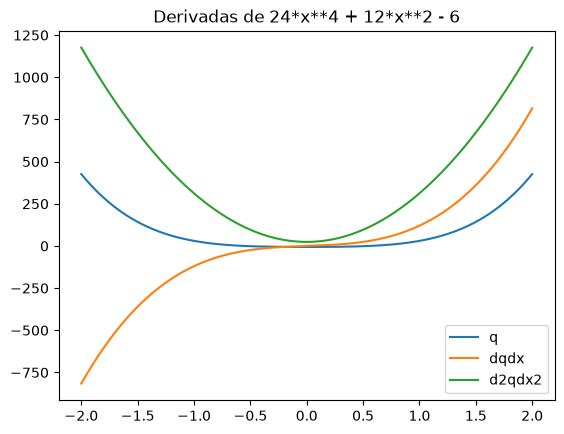

In [44]:
plt.plot(x_vals, q_vals, label="q")
plt.plot(x_vals, dqdx_vals, label="dqdx")
plt.plot(x_vals, d2qdx2_vals, label="d2qdx2")
# plt.plot(x_vals, d3qdx3_vals, label="d3qdx3")
plt.legend()
plt.title(f"Derivadas de {q}")
plt.show()

In [45]:
plt.close()

#### Interpretación

Hasta acá, calculamos derivadas sucesivas simbólicas en `SymPy`. Agreguemos un poco de teoría.

- la primera derivada, genéricamente $f^{\prime} (x)$, se interpreta como:
  - analíticamente: la tasa de variación instantánea de la función
  - geométricamente: la pendiente de la recta tangente en un punto

  Algunos puntos clave:
  - si $f^{\prime}(x) > 0$, entonces la función es creciente
  - si $f^{\prime}(x) < 0$, entonces la función es decreciente
  - si $f^{\prime}(x) = 0$, entonces la función es constante, y el punto donde se cumple esta condición es candidato a un máximo, mínimo o punto de inflexión

- la segunda derivada, genéricamente $f^{\prime \prime} (x)$, se interpreta como:
  - analíticamente: la tasa de aceleración o cambio de la pendiente
  - geométricamente: la curvatura de la función

  Algunos puntos clave:
  - si $f^{\prime \prime}(x) > 0$, entonces la función es cóncava "hacia arriba" (tiene mínimo local)
  - si $f^{\prime \prime}(x) < 0$, entonces la función es cóncava "hacia abajo" (tiene máximo local)
  - si $f^{\prime \prime}(x) = 0$, entonces el punto donde se cumple esta condición es candidato a un punto de inflexión (dependiendo del cambio de signo)

#### Complejizaciones y `sp.simplify`

Supongamos la función 
$$r(x) = (x^{2} + 2 \cdot x + 1) \cdot e^{\ln(x^{2})} + \dfrac{\sin^2(x) + \cos^2(x)}{x}
$$

In [46]:
r = (x**2 + 2*x + 1) * sp.exp(sp.log(x**2)) + (sp.sin(x)**2 + sp.cos(x)**2)/x

Notemos que esta función tiene un montón de redundancias:
- $(x^{2} + 2 \cdot x + 1) = (x + 1)^{2}$
- $e^{\ln(x^{2})} = x^{2}$ para $x > 0$
- $sin^{2}(x) + cos^{2}(x) = 1$

Si deriváramos $r$...

In [47]:
drdx = sp.diff(r, x)

In [48]:
drdx

x**2*(2*x + 2) + 2*x*(x**2 + 2*x + 1) - (sin(x)**2 + cos(x)**2)/x**2

...las redundancias se mantienen.

Pero `sp.simplify` nos permite simplificar esta expresión "lo más posible".

In [49]:
drdx_simpl = sp.simplify(drdx)

In [50]:
drdx_simpl

4*x**3 + 6*x**2 + 2*x - 1/x**2

#### Las otras dos: `.expand()` y `.factor()`

`sp.simplify()` es la herramienta de propósito general: intenta varias estrategias y devuelve lo que
*le parece* más simple. Eso la hace cómoda pero impredecible. Cuando sabés **qué forma** querés, hay
dos funciones específicas que hacen exactamente una cosa:

| Función | Qué hace | Para qué sirve |
|---|---|---|
| `.expand()` | **distribuye** todo: deja la expresión como una suma de términos | ver los coeficientes, identificar el grado, comparar dos expresiones |
| `.factor()` | **factoriza**: deja la expresión como un producto | encontrar las **raíces** a simple vista, cancelar términos |
| `.simplify()` | prueba de todo y elige | cuando no sabés qué forma querés |

> 🔑 **La más útil de las tres para nosotros es `.factor()`**, porque un polinomio factorizado
> **muestra sus raíces escritas**: si queda $(q-4)(q-9)$, los ceros están en $4$ y en $9$ sin hacer
> ninguna cuenta. Y las raíces de la derivada son, justamente, los candidatos a óptimo.

Las tres se pueden escribir como método (`expr.factor()`) o como función (`sp.factor(expr)`): es lo
mismo.


In [51]:
z = sp.symbols("z", real=True)

expr = (z - 4) * (z - 9)

print("Original   :", expr)
print("expand()   :", sp.expand(expr),   "  ← ahora se ven los coeficientes")
print("factor()   :", sp.factor(sp.expand(expr)), "  ← y volvemos: se ven las raíces\n")

# El caso que nos interesa: las raíces de una derivada
B = -z**3 + 18*z**2 - 96*z + 200          # una función de beneficio
dB = sp.diff(B, z)

print("Beneficio        B(z) =", B)
print("Beneficio marginal    =", dB)
print("Factorizado           =", sp.factor(dB), "  ← los candidatos a óptimo son z = 4 y z = 8")

# Comprobación
print("\nRaíces según sp.solve :", sp.solve(dB, z))


Original   : (z - 9)*(z - 4)
expand()   : z**2 - 13*z + 36   ← ahora se ven los coeficientes
factor()   : (z - 9)*(z - 4)   ← y volvemos: se ven las raíces

Beneficio        B(z) = -z**3 + 18*z**2 - 96*z + 200
Beneficio marginal    = -3*z**2 + 36*z - 96
Factorizado           = -3*(z - 8)*(z - 4)   ← los candidatos a óptimo son z = 4 y z = 8

Raíces según sp.solve : [4, 8]


#### Poder de cómputo

El poder de cómputo de `SymPy` es enorme.

Probémoslo.

Sabemos que derivar 
$f(x) = x^{2}$ es simple, incluso a mano.

Proponemos 
$h(x)$:
$$
h(x)=
x^{x}\,e^{\sin(x^{2})}\,\log\!\big(\Gamma(x+1)\big)
\;+\; \operatorname{Ei}(x^{2})\, I_{0}(x)\,\cosh(x)
\;+\; \mathrm{Li}_{2}(-x)^{2}
\;+\; \int_{0}^{\infty} e^{-tx}\,\sin(t^{2})\,dt
\;+\; \sum_{n=1}^{\infty} \frac{\zeta(n+1)}{n!}\,x^{n}
$$

In [52]:
t, n = sp.symbols("t n", real=True)

In [53]:
h = (
    x**x * sp.exp(sp.sin(x**2)) * sp.log(sp.gamma(x + 1))                           # x^x * e^{sin(x^2)} * log(Gamma)
    + sp.Ei(x**2) * sp.besseli(0, x) * sp.cosh(x)                                   # Ei * Bessel I0 * cosh
    + sp.polylog(2, -x)**2                                                          # Li_2(-x)^2
    + sp.Integral(sp.exp(-t*x) * sp.sin(t**2), (t, 0, sp.oo))                        # Integral impropia
    + sp.summation(sp.zeta(n + 1) * x**n / sp.factorial(n), (n, 1, sp.oo))          # Serie infinita
)

In [54]:
h

x**x*exp(sin(x**2))*log(gamma(x + 1)) + cosh(x)*Ei(x**2)*besseli(0, x) + polylog(2, -x)**2 + Integral(exp(-t*x)*sin(t**2), (t, 0, oo)) + Sum(x**n*zeta(n + 1)/factorial(n), (n, 1, oo))

Tomemos la derivada de esto...

In [55]:
dhdx = sp.diff(h, x)

In [56]:
dhdx

2*x*x**x*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2) + x**x*(log(x) + 1)*exp(sin(x**2))*log(gamma(x + 1)) + x**x*exp(sin(x**2))*polygamma(0, x + 1) + sinh(x)*Ei(x**2)*besseli(0, x) + cosh(x)*Ei(x**2)*besseli(1, x) + Integral(-t*exp(-t*x)*sin(t**2), (t, 0, oo)) + Sum(n*x**n*zeta(n + 1)/(x*factorial(n)), (n, 1, oo)) + 2*exp(x**2)*cosh(x)*besseli(0, x)/x + 2*polylog(1, -x)*polylog(2, -x)/x

Simplificando...

In [57]:
dhdx_simpl = sp.simplify(dhdx)

In [58]:
dhdx_simpl

x**x*exp(sin(x**2))*log(x)*log(gamma(x + 1)) + x**x*exp(sin(x**2))*log(gamma(x + 1)) + x**x*exp(sin(x**2))*polygamma(0, x + 1) + 2*x**(x + 1)*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2) - Piecewise((2*sqrt(2)*(-sqrt(2)*sqrt(pi)*x**3*sin(x**2/4)*gamma(-3/4)*gamma(7/4)/32 + sqrt(2)*sqrt(pi)*x**3*cos(x**2/4)*gamma(-1/4)*gamma(5/4)/32 + x**2*(sqrt(2)*sqrt(pi)*x*(-sin(x**2/4)*fresnelc(sqrt(2)*x/(2*sqrt(pi))) + cos(x**2/4)*fresnels(sqrt(2)*x/(2*sqrt(pi))))/16 + 1/8)*gamma(1/4)*gamma(3/4))/(pi*x**2), Abs(arg(x)) < pi/2), (Integral(t*exp(-t*x)*sin(t**2), (t, 0, oo)), True)) + sinh(x)*Ei(x**2)*besseli(0, x) + cosh(x)*Ei(x**2)*besseli(1, x) + Sum(x**(n - 1)*zeta(n + 1)/gamma(n), (n, 1, oo)) + 2*exp(x**2)*cosh(x)*besseli(0, x)/x + 2*polylog(1, -x)*polylog(2, -x)/x

Y todo en...

In [59]:
#@title [código oculto]
import time
start = time.time()
dhdx_time = sp.diff(h, x)
dhdx_simpl_time = sp.simplify(dhdx)
end = time.time()
print(f"{end - start} segundos")

0.9734063148498535 segundos


O calcular la cuarta derivada:

In [60]:
d4hdx4 = sp.diff(h, x, 4)

In [61]:
d4hdx4

48*x**4*x**x*exp(sin(x**2))*log(gamma(x + 1))*sin(x**2)**2 - 96*x**4*x**x*exp(sin(x**2))*log(gamma(x + 1))*sin(x**2)*cos(x**2)**2 + 16*x**4*x**x*exp(sin(x**2))*log(gamma(x + 1))*sin(x**2) + 16*x**4*x**x*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2)**4 - 64*x**4*x**x*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2)**2 - 96*x**3*x**x*(log(x) + 1)*exp(sin(x**2))*log(gamma(x + 1))*sin(x**2)*cos(x**2) + 32*x**3*x**x*(log(x) + 1)*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2)**3 - 32*x**3*x**x*(log(x) + 1)*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2) - 96*x**3*x**x*exp(sin(x**2))*sin(x**2)*cos(x**2)*polygamma(0, x + 1) + 32*x**3*x**x*exp(sin(x**2))*cos(x**2)**3*polygamma(0, x + 1) - 32*x**3*x**x*exp(sin(x**2))*cos(x**2)*polygamma(0, x + 1) - 24*x**2*x**x*(log(x) + 1)**2*exp(sin(x**2))*log(gamma(x + 1))*sin(x**2) + 24*x**2*x**x*(log(x) + 1)**2*exp(sin(x**2))*log(gamma(x + 1))*cos(x**2)**2 - 48*x**2*x**x*(log(x) + 1)*exp(sin(x**2))*sin(x**2)*polygamma(0, x + 1) + 48*x**2*x**x*(log(x) + 1)*exp(sin(x**2))*cos(

Como antes, también podemos obtener valores "particulares" de la derivada (derivada puntual). Para ello, utilizamos `.subs()` y `.evalf()`:

In [62]:
d4hdx4.subs([(x, 2), (t, 1), (n, 2)]).evalf()

118084.483085684

### 📋 Resumen de la Parte 1: el vocabulario de `SymPy`

Todo lo que vimos hasta acá, junto:

| Qué necesito | Cómo se escribe |
|---|---|
| Crear símbolos | `x, y = sp.symbols("x y", real=True, positive=True)` |
| Declarar una función genérica | `f = sp.symbols("f", cls=sp.Function)` y después `f = f(x)` |
| Calcular un límite | `sp.limit(expr, x, valor)` — con `sp.oo` para infinito, `dir="+"` / `dir="-"` para laterales |
| Derivar | `sp.diff(expr, x)` |
| Derivar $n$ veces | `sp.diff(expr, x, n)` |
| Dejar la derivada indicada | `sp.Derivative(expr, x)` |
| Ejecutar lo que está indicado | `.doit()` |
| Evaluar en un punto | `expr.subs(x, 6)` o `expr.subs([(x, 6), (y, 2)])` |
| Convertir a número decimal | `.evalf()` |
| Convertir a función numérica | `sp.lambdify([x, y], expr)` |
| Distribuir | `.expand()` |
| Factorizar (ver las raíces) | `.factor()` |
| Simplificar en general | `.simplify()` |

Falta una sola, y la vemos en la Parte 3, cuando tengamos una ecuación de verdad que resolver:
**`sp.solve()`**.


### La derivada numérica: `NumPy`

Sin embargo, no siempre tenemos una fórmula.

A veces, solo tenemos datos (a través del tiempo, por ejemplo) y queremos ver su tasa de cambio.

Hagamos una base de datos de ejemplo.

La definiremos sobre el siguiente rango:

> ⚠️ **Atención con el nombre de la variable.** En la celda que sigue, `x` deja de ser el **símbolo
> de SymPy** que veníamos usando y pasa a ser un **array de NumPy**. Es el mismo nombre, pero ya no
> es el mismo objeto: a partir de acá, `sp.diff(f, x)` va a fallar.
>
> Es uno de los errores más comunes y más difíciles de detectar, porque no da error en el momento:
> da error mucho después, en una celda que antes funcionaba. Por eso más adelante, cuando volvamos a
> trabajar simbólicamente, vamos a **redefinir los símbolos desde cero**.
>
> 💡 En tus propios notebooks, la forma de evitarlo es usar nombres distintos: `x` para el símbolo y
> `x_vals` para el array.


In [38]:
x = np.linspace(0, 10, 50)

Luego, generaremos dos variantes de la base de datos: una `smooth` (suavizada) y una `noisy` (con el ruido típico de los datos).

In [39]:
y_smooth = np.sin(x)

In [40]:
np.random.seed(42)  # para reproducibilidad
y_noisy = np.sin(x) + np.random.uniform(-0.75, 0.75, size=len(x))

Visualizando ambas series.

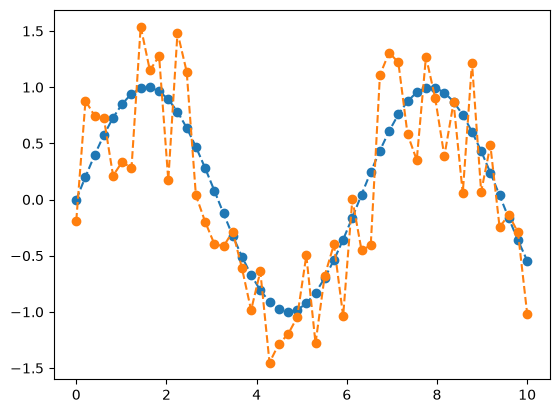

In [41]:
plt.plot(
    x,
    y_smooth,
    "o--")
plt.plot(
    x,
    y_noisy,
    "o--")

### 🔬 Antes de seguir: ¿qué significa derivar datos?

Acá hay una pregunta que conviene hacerse explícitamente, porque es el corazón de esta parte de la
clase: **¿tiene sentido derivar una serie de datos?**

Volvamos a la definición que vimos con `sp.limit`:

$$f^{\prime}(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Esa definición pide **dos cosas** que con datos no tenemos:

1. Que la función esté definida en **todos** los puntos, incluidos los infinitos puntos entre dos
   observaciones.
2. Que podamos hacer $h$ **tan chico como queramos**.

Con datos, ninguna de las dos se cumple. Si medimos las ventas una vez por mes, **no existe** el dato
del mes 3,5. El $h$ más chico posible es un mes, y ahí se termina. **No hay límite que tomar.**

Entonces lo que se hace es lo único que se puede hacer: **quedarse con el cociente incremental y no
tomar el límite**. Eso se llama *diferencia finita*, y es una **aproximación**:

| | Continuo (`SymPy`) | Discreto (`NumPy`) |
|---|---|---|
| Qué hay | una **fórmula** | una **muestra** de puntos |
| $h$ | tiende a cero | **fijo**, es el espaciado entre observaciones |
| El resultado | la derivada **exacta** | una **aproximación** de la derivada |
| Cuánto me puedo equivocar | nada | depende de $h$ y de qué tan suave sea el fenómeno |

**¿Y entonces tiene sentido o no?** Sí, con una condición: que exista un proceso subyacente razonablemente
**suave** y que las observaciones estén lo suficientemente **juntas** para seguirlo. Si medimos la
temperatura cada minuto, la diferencia entre dos mediciones se parece muchísimo a la derivada real.
Si la medimos una vez por mes, no.

**Y cuándo no tiene sentido**, que es lo que vamos a ver enseguida en este notebook: cuando los datos
tienen **ruido**. El motivo es casi aritmético. La fórmula divide por $h$, y $h$ es chico, así que
**divide por un número chico**: cualquier error de medición en el numerador queda multiplicado por
$1/h$. Con $h = 0{,}2$, un ruido de $\pm 0{,}5$ en el dato se convierte en un ruido de $\pm 2{,}5$ en
la derivada. Por eso, derivar datos ruidosos **amplifica el ruido en vez de revelar la señal**, y es
exactamente el problema que vamos a tener que resolver más abajo.

> 🔑 **La regla:** derivar datos siempre *se puede*. Que el resultado *signifique* algo es otra
> pregunta, y hay que hacérsela **antes** de mirar el gráfico.


#### Cálculo por gradiante con `np.gradient`

Empecemos usando `y_smooth`.

Estos datos no distan mucho de una función definida rigurosamente, solo que sin saber la función subyacente.

La forma más fácil de tomar la derivada de este tipo de construcciones es utilizando el [gradiente](https://es.wikipedia.org/wiki/Gradiente); básicamente, la derivada *discreta* en cada punto.

Para ello, utilizamos `np.gradient()`, la función de `NumPy` que devuelve el gradiente de un `array` de $N$ dimensiones.

La sintaxis de `np.gradient` es simple: solo requiere especificar `f`, el `array` $N$-dimensional que contiene las muestras de la función escalar.

También podemos introducir un parámetro opcional, `varargs`, que toma la forma de una `list` que nos da el *espaciado* entre los valores de `f`. Si no es especificado, asume espaciado unitario para todas las dimensiones.

**Qué calcula exactamente.** En los puntos **interiores** usa una *diferencia centrada*, que mira un
punto para cada lado:

$$f^{\prime}(x_i) \approx \frac{f(x_{i+1}) - f(x_{i-1})}{x_{i+1} - x_{i-1}}$$

y en los **extremos**, donde no hay vecino de un lado, usa una diferencia hacia adelante o hacia
atrás con los dos puntos disponibles. Por eso el resultado tiene **exactamente la misma longitud**
que los datos de entrada, a diferencia de `np.diff()`, que devuelve un elemento menos.

| | `np.diff()` | `np.gradient()` |
|---|---|---|
| Qué calcula | la diferencia cruda $f_{i+1} - f_i$ | la **pendiente** estimada en cada punto |
| ¿Divide por el espaciado? | **no** | **sí**, si se lo pasás |
| Longitud del resultado | $n - 1$ | $n$ |
| Para qué se usa | variación entre períodos (mes a mes) | aproximar la derivada de un fenómeno continuo |


Peeeero...los datos no suelen ser tan "lindos".

Tomemos `y_noisy`, y repitamos el cálculo del gradiente.

In [42]:
dnoisy_dx = np.gradient(y_noisy, x)

In [43]:
dnoisy_dx

array([ 5.22795317,  2.28610696, -0.38231179, -1.30401818, -0.94663202,
        0.15948388,  2.94699216,  2.1364044 , -0.64241969, -2.39444387,
        0.51248518,  2.36370686, -3.54832158, -3.26792621, -1.05950211,
       -0.53998398,  0.26898524, -0.47088855, -1.71409942, -0.07489201,
       -1.14329757, -1.58590696,  0.61450961,  0.58404346,  1.72237076,
       -0.56502105, -0.44012611,  2.15419589, -0.88244807,  0.98332129,
        1.43624277, -1.00152259,  3.82330784,  4.20319007,  0.27090313,
       -1.78107722, -2.12968471,  1.69138196,  1.35665011, -2.17034655,
       -0.1000532 , -0.80982224,  0.86906853,  0.03362952, -1.80326168,
       -0.76982633, -1.51591179, -0.11562536, -2.15736873, -3.54821945])

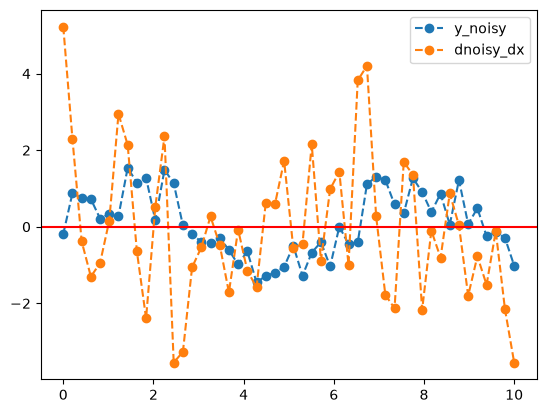

In [44]:
plt.plot(x, y_noisy, "o--", label="y_noisy")
plt.plot(x, dnoisy_dx, "o--", label="dnoisy_dx")
plt.axhline(y=0, color='r', linestyle='-')
plt.legend()

Vemos que no se puede apreciar la diferencia...

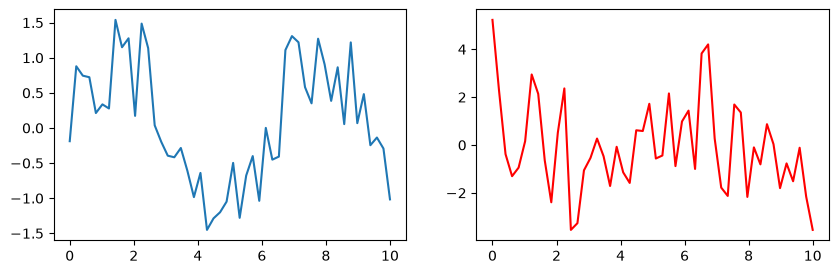

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(x, y_noisy, label="y_noisy")
ax[1].plot(x, dnoisy_dx, label="dnoisy_dx", color="r")

Sigue sin decirnos nada. ¿Por qué?

El ruido no solo se transmite de `y_noisy` a su derivada, sino que se amplifica. Esto impide ver el proceso subyacente.

Entonces, `np.gradient` no es bueno cuando los datos tienen ruido (son *noisy*).

#### *Smoothear*, luego derivar

La mejor forma para trabajar con datos *noisy* es atacar el problema "de raíz": transformamos los datos de *noisy* a *smooth*, y luego trabajamos con los datos para calcular las derivadas.

Se entenderá mejor con un ejemplo. Tomemos datos diarios en dólares corrientes de los precios del *stock* de YPF, entre enero del 2008 y diciembre del 2019.

Usemos `Pandas` y `pd.read_excel`.

In [47]:
ypf = pd.read_excel("https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/YPF.xlsx")

In [48]:
ypf.columns

Index(['date', 'price'], dtype='str')

In [49]:
x = range(len(ypf))

Visualizamos la serie.

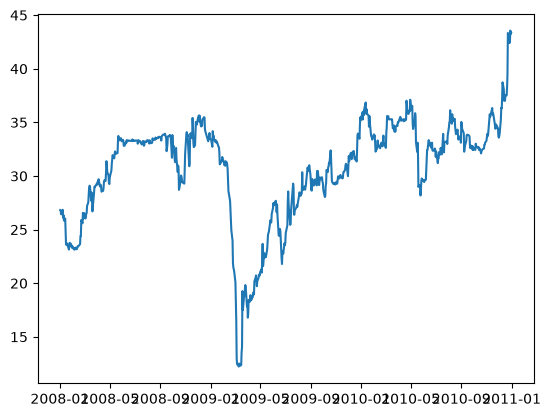

In [50]:
plt.plot(ypf["date"], ypf["price"])

Vemos que es (muy) *noisy*.

Si tomáramos la derivada con `np.gradient` de la función sin *smoothear*...

In [51]:
dypf_dx = np.gradient(ypf["price"], x)

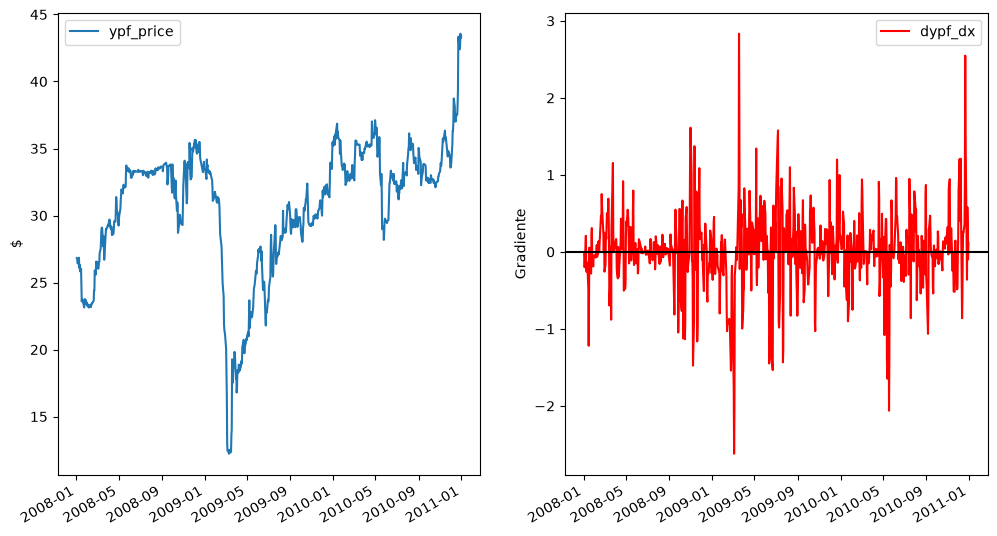

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].plot(
    ypf["date"],
    ypf["price"],
    label="ypf_price")

ax[1].plot(
    ypf["date"],
    dypf_dx,
    label="dypf_dx",
    color="r")

plt.axhline(y=0, color='black', linestyle='-')

ax[0].set_ylabel('$')
ax[1].set_ylabel('Gradiente')

plt.setp(
      [a.get_xticklabels() for a in ax],
      rotation=30,
      horizontalalignment='right')

[a.legend() for a in ax]

plt.show()

¿Qué podemos decir sobre estos datos? Absolutamente nada. La derivada no es lo suficientemente clara como para indicar períodos de crecimiento y decrecimiento del precio de la acción.

¿Cómo podríamos *suavizar* estos datos? Por ejemplo, podríamos hacerlo tomando ventanas de tiempo

Utilizaremos un método de "convolución" para *suavizar* los datos.

La *convolución* es una operación matemática que combina dos funciones para describir la superposición entre ambas. La convolución toma dos funciones, “desliza” una sobre la otra, multiplica los valores de las funciones en todos los puntos de superposición, y suma los productos para crear una nueva función.

En particular, vamos a utilizar un *rolling average* (promedio móvil) con una ventana de tiempo definida arbitrariamente (de 15 días, por ejemplo).

Así, lo que haremos -en orden- será:
1. definir un rectángulo de área igual 1 , para nuestra ventana de tiempo
2. aplicaremos este rectángulo a intervalos definidos de nuestra función

Definamos nuestro rectángulo...

In [53]:
rect = np.ones(15)/15

In [84]:
rect

array([0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667,
       0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667,
       0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667])

Vemos que se trata de 15 valores, cada uno definido como $\dfrac{1}{15}$, de manera que el área del rectángulo es igual a 1.

Luego, utilizamos `np.convolve` para crear una la convolución, una función que devuelve la convolución lineal discreta de dos secuencias uni-dimensionales.

No cubriremos `np.convolve` en profundidad, pero pueden ver más en la [documentación](https://numpy.org/doc/2.0/reference/generated/numpy.convolve.html).

In [54]:
ypf_smooth = np.convolve(ypf["price"], rect, mode="valid")

In [55]:
dypfsmooth_dx = np.gradient(ypf_smooth, x[7:-7])

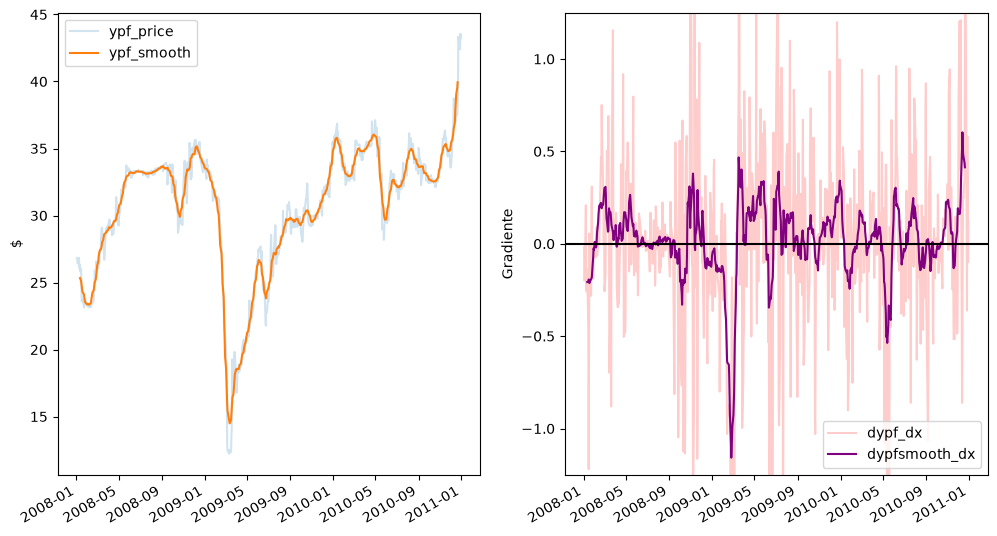

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Noisy
ax[0].plot(
    ypf["date"],
    ypf["price"],
    label="ypf_price",
    alpha=0.2)

ax[1].plot(
    ypf["date"],
    dypf_dx,
    label="dypf_dx",
    color="r",
    alpha=0.2)

# Smooth
ax[0].plot(
    ypf["date"][7:-7],
    ypf_smooth,
    label="ypf_smooth")

ax[1].plot(
    ypf["date"][7:-7],
    dypfsmooth_dx,
    label="dypfsmooth_dx",
    color="purple")

plt.axhline(y=0, color='black', linestyle='-')

ax[1].set_ylim(-1.25,1.25)
ax[0].set_ylabel('$')
ax[1].set_ylabel('Gradiente')

plt.setp(
      [a.get_xticklabels() for a in ax],
      rotation=30,
      horizontalalignment='right')

[a.legend() for a in ax]

plt.show()

## Derivando funciones organizacionales

Apliquemos todo lo visto a funciones organizacionales.

### Monotonía vía derivada

Supongamos funciones típicas de:
- ingreso total (demanda lineal): $R(q) = a \cdot q - b \cdot q^{2}$
- costo total: $C(q) = c_{0} + c_{1} \cdot q + c_{2} \cdot q^{2}$
- beneficio total: $R(q) - C(q)$

Las definimos con `SymPy`.

Primero, definimos los símbolos.

In [88]:
q = sp.symbols('q', real=True)
a, b, c = sp.symbols("a b c", real=True)
F, c0, c1, c2, c3 = sp.symbols("F c0 c1 c2 c3", real=True)

Luego, definimos las funciones.

Primero, la función de demanda inversa, $p(q)$:

In [89]:
p = a - b * q + c * sp.log(1+q)

Luego, el ingreso total:

In [90]:
R = p * q

In [91]:
R

q*(a - b*q + c*log(q + 1))

De igual manera, definimos la función de costo total:

In [92]:
C = F + c0*q - c1 * (q**2) + c2 * (q**3) + c3 * (sp.sqrt(q))

In [93]:
C

F + c0*q - c1*q**2 + c2*q**3 + c3*sqrt(q)

Por último, el beneficio total, $B(q)$, siendo la diferencia entre el ingreso total y el costo total: $$B(q) = R(q) - C(q)$$

In [94]:
B = R - C

In [95]:
B

-F - c0*q + c1*q**2 - c2*q**3 - c3*sqrt(q) + q*(a - b*q + c*log(q + 1))

Ahora, buscamos las funciones marginales a partir de las funciones totales.

El ingreso marginal, el costo marginal y el beneficio marginal son conceptos económicos derivados de la función de ingreso, costo y beneficio respectivamente. Cada uno se interpreta como la variación en la magnitud total correspondiente cuando se produce o vende una unidad adicional:
- Ingreso marginal (MR): es la variación del ingreso total cuando la empresa vende una unidad adicional de producto. Matemáticamente, es la derivada del ingreso total respecto a la cantidad vendida $$ MR = \dfrac{d R(q)}{d q}$$

  Indica cuánto dinero extra recibe la empresa por vender una unidad adicional.

- Costo marginal (MC): es la variación del costo total cuando se produce una unidad adicional de producto. Se define como la derivada del costo total respecto a la cantidad producida:  $$ MC(q) = \dfrac{d C(q)}{d q}$$

  Representa el costo adicional de producir una unidad más.

- Beneficio marginal (MB): es la variación del beneficio total al producir o vender una unidad más. Como el beneficio se define como ingreso menos costo ($B(q) = R(q) - C(q)$), el beneficio marginal se obtiene derivando esa función: $$ MB(q) = \dfrac{d B(q)}{d q} = MR(q) - MC(q)$$

  Indica cuánto aumenta (o disminuye) el beneficio por la última unidad producida o vendida

Ahora, las definimos simbólicamente en `SymPy`:

In [96]:
MR = sp.diff(R, q)
MC = sp.diff(C, q)
MB = sp.diff(B, q)

Y, de paso, definimos también las segundas derivadas en `SymPy`:

In [97]:
dMR = sp.diff(R, q, 2)
dMC = sp.diff(C, q, 2)
dMB = sp.diff(B, q, 2)

Definamos un rango de valores.

In [98]:
q_vals = np.linspace(0, 20, 200)

Definimos valores para los parámetros.

In [99]:
params = {
    a: 160,
    b: 6,
    c: 0.8,
    F: 20,
    c0: 12,
    c1: 2.5,
    c2: 0.15,
    c3: 3
}

Ahora, definamos cada objeto de `sp.lambdify`, siguiendo la sintaxis correspondiente.

In [100]:
R_f = sp.lambdify(q, R.subs(params))
C_f = sp.lambdify(q, C.subs(params))
B_f = sp.lambdify(q, B.subs(params))
MR_f = sp.lambdify(q, MR.subs(params))
MC_f = sp.lambdify(q, MC.subs(params))
MB_f = sp.lambdify(q, MB.subs(params))
dMR_f = sp.lambdify(q, dMR.subs(params))
dMC_f = sp.lambdify(q, dMC.subs(params))
dMB_f = sp.lambdify(q, dMB.subs(params))

Evaluemos cada objeto de `sp.lambdify` a lo largo de los valores de $x$ dados.

In [101]:
R_vals = R_f(q_vals)
C_vals = C_f(q_vals)
B_vals = B_f(q_vals)
MR_vals = MR_f(q_vals)
MC_vals = MC_f(q_vals)
MB_vals = MB_f(q_vals)
dMR_vals = dMR_f(q_vals)
dMC_vals = dMC_f(q_vals)
dMB_vals = dMB_f(q_vals)

<lambdifygenerated-9>:2: RuntimeWarning: divide by zero encountered in divide
  return 0.45*q**2 - 5.0*q + 12 + (3/2)/sqrt(q)
<lambdifygenerated-10>:2: RuntimeWarning: divide by zero encountered in divide
  return -0.45*q**2 + q*(-6 + 0.8/(q + 1)) - 1.0*q + 0.8*log(q + 1) + 148 - (3/2)/sqrt(q)
<lambdifygenerated-12>:2: RuntimeWarning: divide by zero encountered in divide
  return 0.9*q - 5.0 - (3/4)/q**(3/2)
<lambdifygenerated-13>:2: RuntimeWarning: divide by zero encountered in divide
  return -0.9*q - 0.8*q/(q + 1)**2 - 7.0 + 1.6/(q + 1) + (3/4)/q**(3/2)


#### Determinación de intervalos relevantes (crecimiento y decrecimiento)

Nuestro objetivo, ahora, es determinar intervalos de crecimiento y decrecimiento de las funciones modeladas más arriba (y, más en general, de fenómenos organizacionales).

Nos valdremos, en primera instancia, de un análisis aritmético.

Sea una función total $f(x)$ (puede ser $I(q)$, $C(q)$ o $B(q)$).

Para saber si la función $f(x)$ es (de)creciente en un punto, se calcula la derivada primera, $f^{\prime}(x)$: $$f^{\prime}(x) = \frac{df}{dx} $$

que, como dijimos, mide la *pendiente* de la curva.

Si...

- ... $ f^{\prime}(x) > 0 $ en un intervalo, la función es **creciente** en ese intervalo.  
- ... $ f^{\prime}(x) < 0 $ en un intervalo, la función es **decreciente** en ese intervalo.  
- ... $ f^{\prime}(x) = 0 $, se obtiene un **punto crítico**: puede ser máximo, mínimo o punto de inflexión (esto se afina con la segunda derivada).

Analicemos, entonces, la segunda derivada, $f^{\prime \prime}(x)$: $$f^{\prime \prime}(x) = \frac{d^2 f}{dx^2}$$

que mide la *curvatura* de la función, es decir, cómo cambia la pendiente de la función en cada punto.

Si...
- ... $ f^{\prime \prime}(x) > 0 $, la función es *cóncava hacia arriba* y tiene forma de "U".  
  - el punto crítico identificado con $ f^{\prime}(x) = 0 $ es un **mínimo local**.
- ... $ f^{\prime \prime}(x) < 0 $, la función es *cóncava hacia abajo* y tiene forma de "U" invertida.  
  - el punto crítico identificado con $ f^{\prime}(x) = 0 $ es un **máximo local**.  

- ... $ f^{\prime \prime}(x) = 0 $, el punto puede ser de **inflexión** (cambio en la curvatura).

Con toda esta información...*plotteemos*.

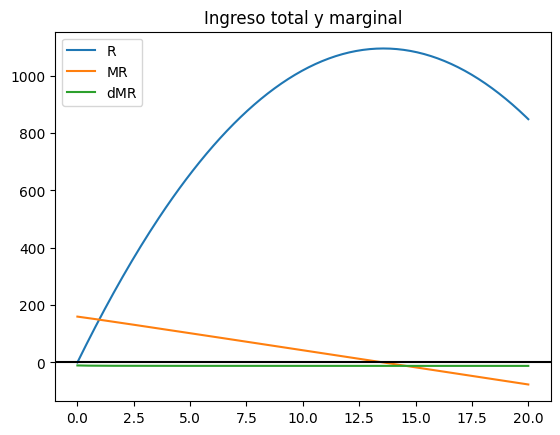

In [102]:
plt.plot(q_vals, R_vals, label="R")
plt.plot(q_vals, MR_vals, label="MR")
plt.plot(q_vals, dMR_vals, label="dMR")
plt.legend()
plt.axhline(y=0, color='black', linestyle='-')
plt.title("Ingreso total y marginal")
plt.show()

Notamos que, en el caso del ingreso, la derivada (es decir, el ingreso marginal, $MR$) es 0 (candidato al óptimo) en aproximadamente...

In [103]:
print(f"q = {q_vals[(np.abs(MR_vals - 0)).argmin()]:2f}")

q = 13.567839


...donde se verifica que la segunda derivada es...

In [104]:
print(f"dMR = {dMR_vals[(np.abs(MR_vals - 0)).argmin()]:2f}")

dMR = -11.941315


... por lo que la función es *cóncava hacia abajo* y el punto es un *máximo local*.

¿Qué sucede en el lado del costo?

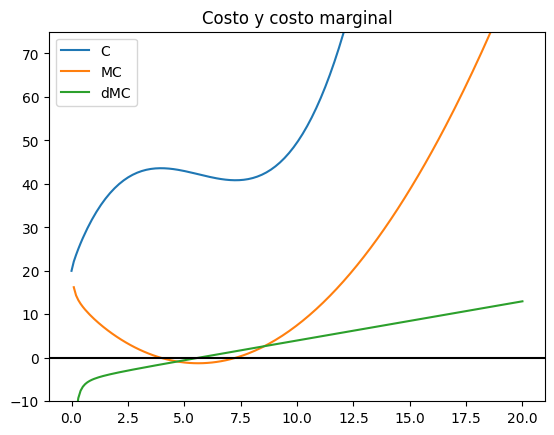

In [105]:
plt.plot(q_vals, C_vals, label="C")
plt.plot(q_vals, MC_vals, label="MC")
plt.plot(q_vals, dMC_vals, label="dMC")
plt.ylim(-10, 75)
plt.legend()
plt.axhline(y=0, color='black', linestyle='-')
plt.title("Costo y costo marginal")

plt.show()

Notamos que, ahora, hay 2 valores que generan que el costo marginal ($MC$) se iguale a 0:

In [106]:
for q in sorted(np.argsort(np.abs(MC_vals - 0))[:2]):
  print(f"q = {q_vals[q]:2f}")

q = 3.919598
q = 7.236181


Sin embargo, una inspección gráfica rápida nos muestra que uno de ellos es un máximo local, y otro es un mínimo local...

In [107]:
for q in sorted(np.argsort(np.abs(MC_vals - 0))[:2]):
  print(f"{q_vals[q]:2f}: dMR = {dMC_vals[q]:2f}")

3.919598: dMR = -1.569011
7.236181: dMR = 1.474033


De esta manera, se denota que:
- para $q \approx 3.92$, $C^{\prime \prime} (q) < 0$, por lo que la función es *cóncava hacia abajo* y el punto es un *máximo local*.
- para $q \approx 7.24$, $C^{\prime \prime} (q) > 0$, por lo que la función es *cóncava hacia arriba* y el punto es un *mínimo local*.

Por último, verifiquemos el lado del beneficio.

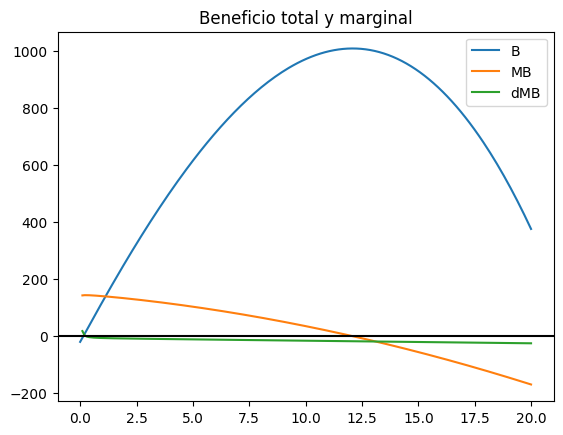

In [108]:
plt.plot(q_vals, B_vals, label="B")
plt.plot(q_vals, MB_vals, label="MB")
plt.plot(q_vals, dMB_vals, label="dMB")
plt.legend()
plt.axhline(y=0, color='black', linestyle='-')
plt.title("Beneficio total y marginal")
plt.show()

Notamos que, en el caso del beneficio, la derivada (es decir, el ingreso marginal, $MR$) es 0 (candidato al óptimo) en aproximadamente...

In [109]:
print(f"q = {q_vals[(np.abs(MB_vals - 0)).argmin()]:2f}")

q = 12.060302


...donde se verifica que la segunda derivada es...

In [110]:
print(f"dMB = {dMB_vals[(np.abs(MB_vals - 0)).argmin()]:2f}")

dMB = -17.770420


... por lo que la función es *cóncava hacia abajo* y el punto es un *máximo local*.

Por último, nótese que se cumple que...

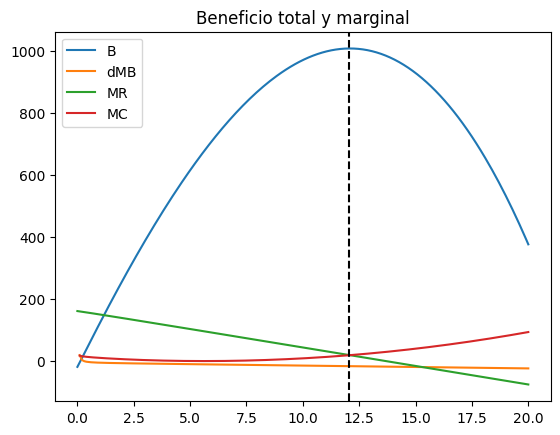

In [111]:
plt.plot(q_vals, B_vals, label="B")
plt.plot(q_vals, dMB_vals, label="dMB")
plt.plot(q_vals, MR_vals, label="MR")
plt.plot(q_vals, MC_vals, label="MC")
plt.axvline(q_vals[(np.abs(MB_vals - 0)).argmin()],
            color='black',
            linestyle='--')

plt.legend()
plt.title("Beneficio total y marginal")
plt.show()

... el ingreso marginal ($MR$) y el costo marginal ($MC$) se igualan en...

In [112]:
print(f"q = {q_vals[(np.abs(MB_vals - 0)).argmin()]:2f}")

q = 12.060302


...donde se optimiza la función de beneficio.

---
# 📝 Ejercicios

La derivada, en gestión, responde siempre la misma pregunta: **¿qué pasa si muevo esto un poquito?**
Cuánto cambia el costo si produzco una unidad más, cuánto cae la demanda si subo un peso el precio,
en qué punto conviene parar. Estos ejercicios entrenan esa lectura.

> 💡 Resolvé **primero con SymPy** (la fórmula exacta) y después verificá **con NumPy** sobre valores
> concretos. Que las dos den lo mismo es la mejor señal de que no te equivocaste.

### ✅ Ejercicio 1 — Costo marginal de una fábrica

Una planta tiene la siguiente función de costo total, con $q$ en unidades:

$$C(q) = 2.500.000 + 18.000q + 6q^2$$

1. Obtené el **costo marginal** $C'(q)$ con SymPy.
2. Calculá el costo marginal en $q = 200$, $q = 800$ y $q = 1.500$.
3. ¿Por qué el costo marginal **crece** con la cantidad? ¿Qué está representando ese término $6q^2$?
4. Compará el costo marginal en $q=800$ contra la diferencia $C(801) - C(800)$. ¿Por qué no dan
   exactamente igual, y por qué se parecen tanto?

In [117]:
import sympy as sp

q = sp.Symbol("q", positive=True)
C = 2_500_000 + 18_000*q + 6*q**2

# Tu código acá

### ✅ Ejercicio 2 — El precio que maximiza el ingreso

Comercial estima que la demanda de un servicio responde a $p(q) = 90.000 - 150q$.

1. Escribí el **ingreso total** $I(q)$ y obtené el **ingreso marginal** $I'(q)$.
2. Encontrá la cantidad donde el ingreso marginal se hace **cero**. ¿Qué significa ese punto?
3. Verificá con la **segunda derivada** que efectivamente es un máximo y no un mínimo.
4. ¿Qué precio hay que cobrar para vender esa cantidad?

In [118]:
# Tu código acá

### ✅ Ejercicio 3 — Leer la variación de una serie real

No siempre hay una fórmula: muchas veces hay **datos**. Estas son las ventas mensuales de una
sucursal durante un año:

```python
ventas = np.array([420, 445, 470, 505, 530, 545, 550, 548, 540, 525, 500, 470])
```

1. Calculá la **variación mes a mes** con `np.diff()`. ¿Qué representa cada número?
2. ¿En qué mes las ventas **dejaron de crecer**? Encontralo mirando dónde la variación cambia de signo.
3. Graficá las ventas y, debajo, su variación. Marcá con una línea vertical el mes del pico.
4. **La pregunta de gestión:** el gerente ve que en el mes 8 las ventas cayeron y quiere actuar.
   Mirando la serie completa, ¿le dirías que es una caída puntual o que venía anunciándose?

In [119]:
import numpy as np
import matplotlib.pyplot as plt

ventas = np.array([420, 445, 470, 505, 530, 545, 550, 548, 540, 525, 500, 470])

# Tu código acá

### ✅ Ejercicio 4 — Elasticidad con derivada

Con la demanda del Ejercicio 2, $p(q) = 90.000 - 150q$:

1. Despejá la demanda como $q(p)$ y calculá $\dfrac{dq}{dp}$.
2. Escribí la **elasticidad precio** $\varepsilon = \dfrac{dq}{dp} \cdot \dfrac{p}{q}$ como
   función de $p$.
3. Evaluala en $p = 30.000$ y en $p = 70.000$. ¿En cuál de los dos precios conviene **subir** el precio?
4. Encontrá el precio donde la elasticidad vale exactamente $-1$. ¿Qué tiene de especial ese punto?
   Compará tu respuesta con el máximo de ingreso del Ejercicio 2.

In [120]:
# Tu código acá

### ✅ Ejercicio 5 — Monotonía: ¿hasta dónde conviene producir?

Una empresa tiene beneficio $B(q) = -3q^2 + 2.400q - 180.000$.

1. Encontrá los intervalos donde el beneficio **crece** y donde **decrece**, usando el signo de $B'(q)$.
2. Determiná la cantidad de **beneficio máximo** y cuánto se gana ahí.
3. Encontrá los dos puntos donde $B(q) = 0$ (los puntos de equilibrio).
4. Graficá $B(q)$ marcando el máximo y los dos equilibrios.
5. **Interpretación:** entre los dos puntos de equilibrio la empresa gana plata. ¿Por qué producir
   *más* que el óptimo empeora el resultado, si estamos vendiendo más unidades?

In [121]:
# Tu código acá